# MODELLO DI PREVISIONE PER IL MERCATO IMMOBILIARE

## Preparazione del Dataset

#### Importazione librerie

In [678]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.model_selection import learning_curve

Elimino i warnings di jupyter notebook per un outpu più ordinato

In [679]:
import warnings
warnings.filterwarnings('ignore')

#### Caricamento dei dati

In [680]:
df = pd.read_csv("housing.csv")
df.head()
df.info()   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    int64
 6   guestroom         545 non-null    int64
 7   basement          545 non-null    int64
 8   hotwaterheating   545 non-null    int64
 9   airconditioning   545 non-null    int64
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    int64
 12  furnishingstatus  545 non-null    int64
dtypes: int64(13)
memory usage: 55.5 KB


## Data Preprocessing

#### Controllo valori mancanti

In [681]:
print("Valori mancanti per colonna:")
print(df.isnull().sum())


Valori mancanti per colonna:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


Non ci sono valori mancanti.

#### Rimozione degli outlier da "price" e "area" per aumentare l'efficacia del modello

Rimuoverò gli outlier solamente dalle due uniche due features non categoriche o binarie.

In [682]:
for col in ['price', 'area']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print("Shape dopo rimozione outlier su price e area:", df.shape)

Shape dopo rimozione outlier su price e area: (517, 13)


#### Codifica delle variabili categoriche tramite One-Hot-Encoding

In [683]:
cat_cols = df.select_dtypes(include='object').columns
print("Colonne categoriche:", cat_cols)
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df.head()

Colonne categoriche: Index([], dtype='object')


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
15,9100000,6000,4,1,2,1,0,1,0,0,2,0,2
16,9100000,6600,4,2,2,1,1,1,0,1,1,1,0
17,8960000,8500,3,2,4,1,0,0,0,1,2,0,1
18,8890000,4600,3,2,2,1,1,0,0,1,2,0,1
19,8855000,6420,3,2,2,1,0,0,0,1,1,1,2


#### Matrice di correlazione

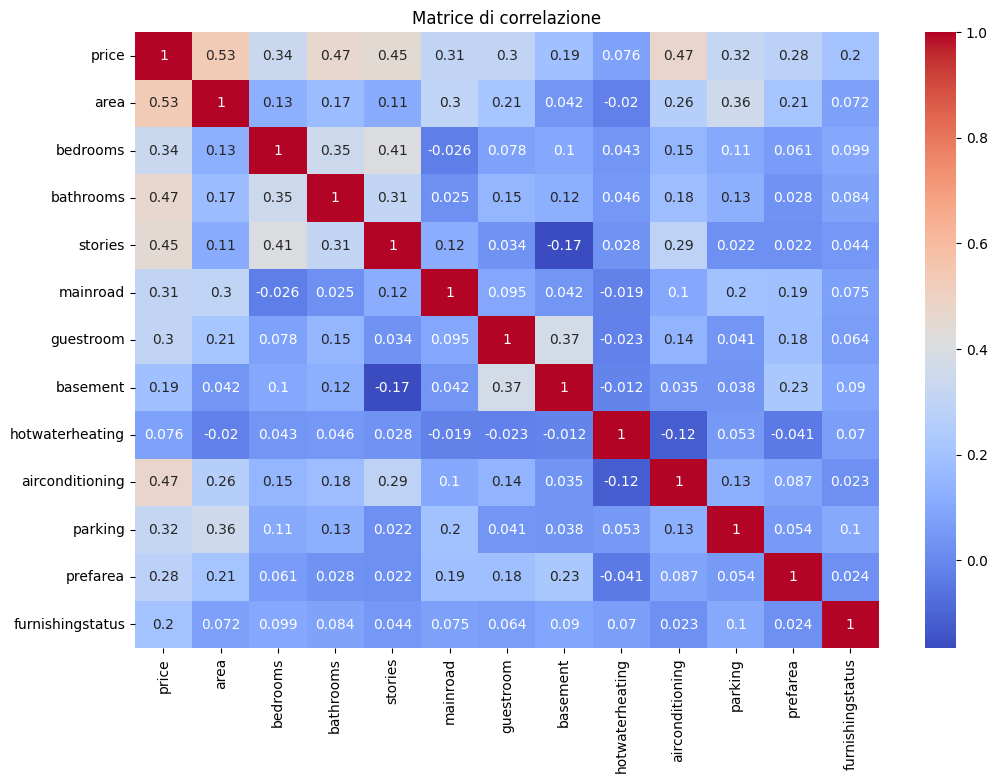

price               1.000000
area                0.533186
airconditioning     0.471706
bathrooms           0.466483
stories             0.446839
bedrooms            0.335328
parking             0.321058
mainroad            0.307185
guestroom           0.303994
prefarea            0.280808
furnishingstatus    0.201183
basement            0.190117
hotwaterheating     0.075979
Name: price, dtype: float64


In [684]:

corr = df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Matrice di correlazione")
plt.show()

print(corr["price"].sort_values(ascending=False))


Si nota dalla matrice correlazione che la feature "hotwaterheating" ha una correlazione molto bassa con "price" e potrebbe essre utile eliminarla per l'efficacia del modello.
Inoltre non sembrano esserci feature con correlazioni forti tra di loro, quindi non sembra esserci multicollinearità grave.

In [685]:
cols_to_drop = ['hotwaterheating']
df = df.drop(cols_to_drop, axis=1)

#### Standardizzazione dei dati

In [686]:
RANDOM_SEED = 1
X = df.drop('price', axis=1)
y = df['price']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_SEED)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## Implementazione dei modelli di regressione

#### Cerco i migliori iperparametri per i modelli


In [687]:
param_grid_ridge = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}
ridge = Ridge()
grid_ridge = GridSearchCV(ridge, param_grid_ridge, cv=5, scoring='r2')
grid_ridge.fit(X_train, y_train)
print("Migliori iperparametri Ridge:", grid_ridge.best_params_)


param_grid_lasso = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}
lasso = Lasso()
grid_lasso = GridSearchCV(lasso, param_grid_lasso, cv=5, scoring='r2')
grid_lasso.fit(X_train, y_train)
print("Migliori iperparametri Lasso:", grid_lasso.best_params_)


param_grid_elastic = {
    'alpha': [0.01, 0.1, 1, 10, 100],
    'l1_ratio': [0.1, 0.5, 0.7, 0.9, 1]
}
elastic = ElasticNet()
grid_elastic = GridSearchCV(elastic, param_grid_elastic, cv=5, scoring='r2')
grid_elastic.fit(X_train, y_train)
print("Migliori iperparametri ElasticNet:", grid_elastic.best_params_)

Migliori iperparametri Ridge: {'alpha': 10}
Migliori iperparametri Lasso: {'alpha': 100}
Migliori iperparametri ElasticNet: {'alpha': 1, 'l1_ratio': 0.9}


#### Definisco la funzione per valutare i modelli

In [688]:
def evaluate_model(model, dataset):
    x, y = dataset
    y_pred = model.predict(x)
    print(f"MSE: {mean_squared_error(y,y_pred):.3f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y,y_pred)):.3f}")
    print(f"R^2: {r2_score(y, y_pred):.3f}")

#### Implementazione ed addestramento modello Ridge

In [689]:
Ridge()
modelR = Ridge(alpha=10)
modelR.fit(X_train, y_train)

,alpha,10
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


#### Implementazione ed addestramento modello Lasso

In [690]:
Lasso()
modelL = Lasso(alpha=100)
modelL.fit(X_train, y_train)

,alpha,100
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


#### Implementazione ed addestramento modello ElasticNet

In [691]:
ElasticNet()
modelE = ElasticNet(alpha=1, l1_ratio=0.9)
modelE.fit(X_train, y_train)

,alpha,1
,l1_ratio,0.9
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


#### Valuto i tre modelli

In [692]:
print("\nValutazione del set_train con modello Ridge:")
print(evaluate_model(modelR, (X_train, y_train)))
print("\nValutazione del set_test con modello Ridge:")
print(evaluate_model(modelR, (X_test, y_test)))
print("Valutazione del set_train con modello Lasso:")
print(evaluate_model(modelL, (X_train, y_train)))
print("\nValutazione del set_test con modello Lasso:")
print(evaluate_model(modelL, (X_test, y_test)))
print("Valutazione del set_train con modello ElasticNet:")
print(evaluate_model(modelE, (X_train, y_train)))
print("\nValutazione del set_test con modello Elasticnet:")
print(evaluate_model(modelE, (X_test, y_test)))


Valutazione del set_train con modello Ridge:
MSE: 882919532482.019
RMSE: 939637.979
R^2: 0.655
None

Valutazione del set_test con modello Ridge:
MSE: 881210529235.736
RMSE: 938728.144
R^2: 0.644
None
Valutazione del set_train con modello Lasso:
MSE: 882571533979.662
RMSE: 939452.784
R^2: 0.655
None

Valutazione del set_test con modello Lasso:
MSE: 881985669870.057
RMSE: 939140.921
R^2: 0.644
None
Valutazione del set_train con modello ElasticNet:
MSE: 886592264200.413
RMSE: 941590.285
R^2: 0.654
None

Valutazione del set_test con modello Elasticnet:
MSE: 882002269614.174
RMSE: 939149.759
R^2: 0.644
None


#### Utilizzo la cross-validation su Ridge, Lasso ed ElasticNet

definisco la funzione di valutazione

In [693]:
def evaluate_model_cv(model, X, y, cv=5):
    kf = KFold(n_splits=cv, shuffle=True, random_state=RANDOM_SEED)
    mse_train, rmse_train, r2_train = [], [], []
    mse_test, rmse_test, r2_test = [], [], []
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        poly = PolynomialFeatures(degree=2)
        X_train = poly.fit_transform(X_train)
        X_test = poly.transform(X_test)
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
        model.fit(X_train, y_train)
     
        y_pred_train = model.predict(X_train)
        mse_train.append(mean_squared_error(y_train, y_pred_train))
        rmse_train.append(np.sqrt(mean_squared_error(y_train, y_pred_train)))
        r2_train.append(r2_score(y_train, y_pred_train))
     
        y_pred_test = model.predict(X_test)
        mse_test.append(mean_squared_error(y_test, y_pred_test))
        rmse_test.append(np.sqrt(mean_squared_error(y_test, y_pred_test)))
        r2_test.append(r2_score(y_test, y_pred_test))
    print("TRAIN SET :")
    print(f"MSE medio: {np.mean(mse_train):.3f}")
    print(f"RMSE medio: {np.mean(rmse_train):.3f}")
    print(f"R^2 medio: {np.mean(r2_train):.3f}")
    print("TEST SET :")
    print(f"MSE medio: {np.mean(mse_test):.3f}")
    print(f"RMSE medio: {np.mean(rmse_test):.3f}")
    print(f"R^2 medio: {np.mean(r2_test):.3f}")

Valuto i modelli con cross-validation

In [694]:
print("Ridge con cross-validation:")
evaluate_model_cv(Ridge(alpha=10), X, y)
print("\n\nLasso con cross-validation:")
evaluate_model_cv(Lasso(alpha=100), X, y)
print("\n\n$ElasticNet con cross validation:")
evaluate_model_cv(ElasticNet(alpha=1, l1_ratio=0.9), X, y)

Ridge con cross-validation:
TRAIN SET :
MSE medio: 673977853910.420
RMSE medio: 820929.396
R^2 medio: 0.734
TEST SET :
MSE medio: 930881021135.645
RMSE medio: 963958.385
R^2 medio: 0.631


Lasso con cross-validation:
TRAIN SET :
MSE medio: 625991830811.146
RMSE medio: 791156.759
R^2 medio: 0.753
TEST SET :
MSE medio: 1042551587550.098
RMSE medio: 1018518.016
R^2 medio: 0.583


$ElasticNet con cross validation:
TRAIN SET :
MSE medio: 736259247503.962
RMSE medio: 858001.297
R^2 medio: 0.710
TEST SET :
MSE medio: 910004426688.481
RMSE medio: 952869.251
R^2 medio: 0.640


Analizzando i risultati mi affiderei al modello ELasticNet avendo un R^2 piu alto rispetto agli altri.

## Visualizzo i risultati

#### Visualizzo la Learning Curve per modello Ridge

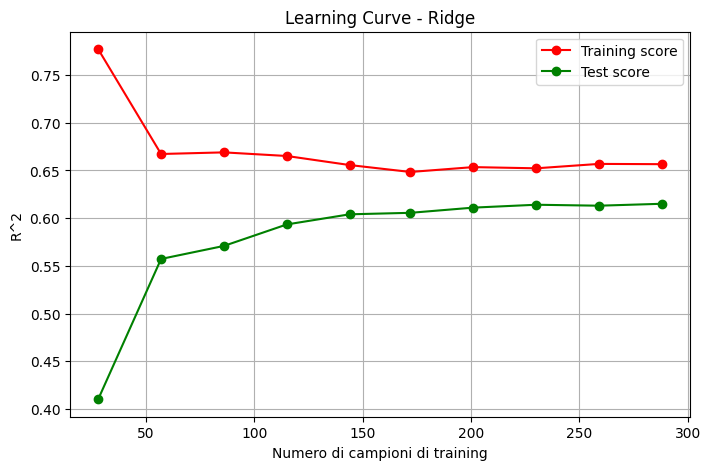

In [695]:
train_sizes, train_scores_Ridge, test_scores_Ridge = learning_curve(
    Ridge(), X_train, y_train, cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=RANDOM_SEED
)
train_scores_mean_Ridge = np.mean(train_scores_Ridge, axis=1)
test_scores_mean_Ridge = np.mean(test_scores_Ridge, axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_scores_mean_Ridge, 'o-', color='r', label='Training score')
plt.plot(train_sizes, test_scores_mean_Ridge, 'o-', color='g', label='Test score')
plt.xlabel('Numero di campioni di training')
plt.ylabel('R^2')
plt.title('Learning Curve - Ridge')
plt.legend()
plt.grid()
plt.show()

#### Visualizzo la Learning Curve per modello Lasso

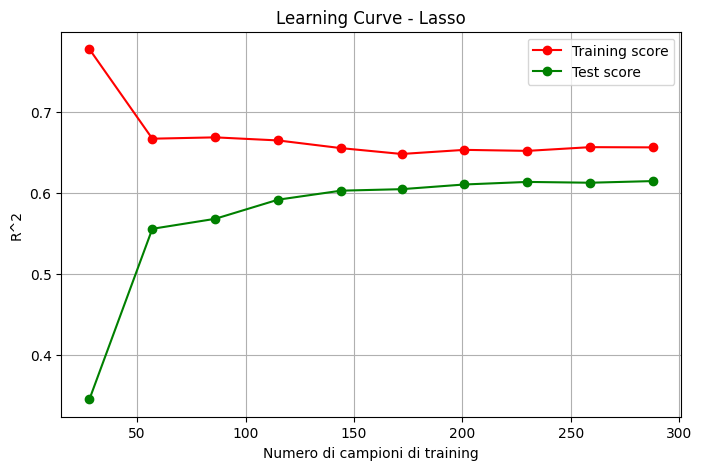

In [696]:
train_sizes, train_scores_Lasso, test_scores_Lasso = learning_curve(
    Lasso(), X_train, y_train, cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=RANDOM_SEED
)
train_scores_mean_Lasso = np.mean(train_scores_Lasso, axis=1)
test_scores_mean_Lasso = np.mean(test_scores_Lasso, axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_scores_mean_Lasso, 'o-', color='r', label='Training score')
plt.plot(train_sizes, test_scores_mean_Lasso, 'o-', color='g', label='Test score')
plt.xlabel('Numero di campioni di training')
plt.ylabel('R^2')
plt.title('Learning Curve - Lasso')
plt.legend()
plt.grid()
plt.show()

#### Visualizzo la Learning Curve per modello ElasticNet

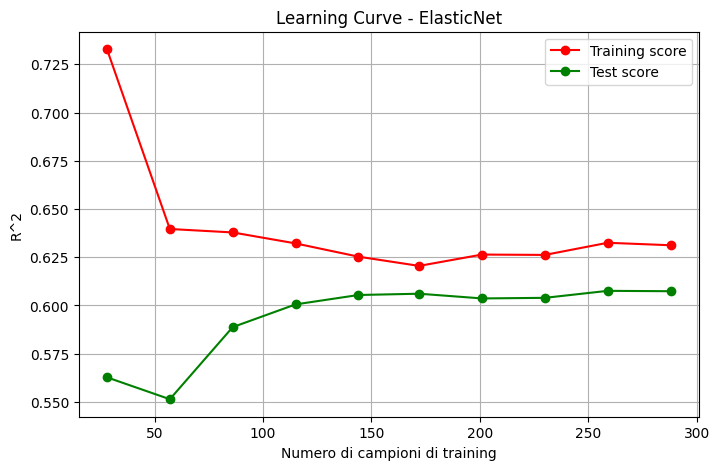

In [697]:
train_sizes, train_scores_ElasticNet, test_scores_ElasticNet = learning_curve(
    ElasticNet(), X_train, y_train, cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=RANDOM_SEED
)
train_scores_mean_ElasticNet = np.mean(train_scores_ElasticNet, axis=1)
test_scores_mean_ElasticNet = np.mean(test_scores_ElasticNet, axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_scores_mean_ElasticNet, 'o-', color='r', label='Training score')
plt.plot(train_sizes, test_scores_mean_ElasticNet, 'o-', color='g', label='Test score')
plt.xlabel('Numero di campioni di training')
plt.ylabel('R^2')
plt.title('Learning Curve - ElasticNet')
plt.legend()
plt.grid()
plt.show()

Le tre learning curve mostrano come varia il punteggio R² al crescere del numero di campioni di training per Ridge, Lasso ed ElasticNet.

Tutti i modelli presentano un gap tra training score (curva rossa) e test score (curva verde): il training score è sempre più alto, ma la distanza tra le due curve si riduce all’aumentare dei dati, segno che il modello generalizza meglio con più dati.

Ridge e Lasso hanno un comportamento molto simile: il training score si stabilizza intorno a 0.66-0.67, mentre il test score si assesta poco sopra 0.61.

ElasticNet mostra valori leggermente inferiori sia per il training che per il test score, ma la differenza tra train e test è più contenuta, segno di una regolarizzazione più efficace e minore rischio di overfitting.

Anche se Ridge e Lasso ottengono un test score leggermente superiore, ElasticNet mostra una maggiore stabilità e una minore differenza tra training e test, suggerendo una migliore capacità di generalizzazione. Inoltre, ElasticNet combina i vantaggi di Ridge e Lasso, risultando più robusto in presenza di feature correlate.

Per questi motivi sceglierei ElasticNet come modello finale, privilegiando la sua robustezza e la sua capacità di evitare l’overfitting, anche a fronte di un piccolo sacrificio in termini di R².

#### Visualizzo la distribuzione dei residui per il modello Ridge

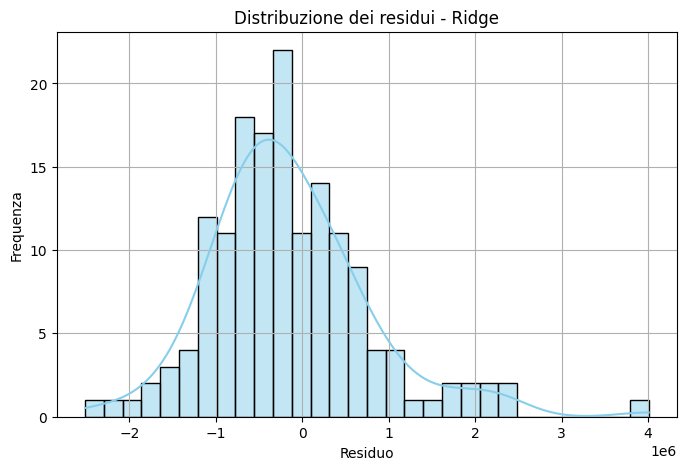

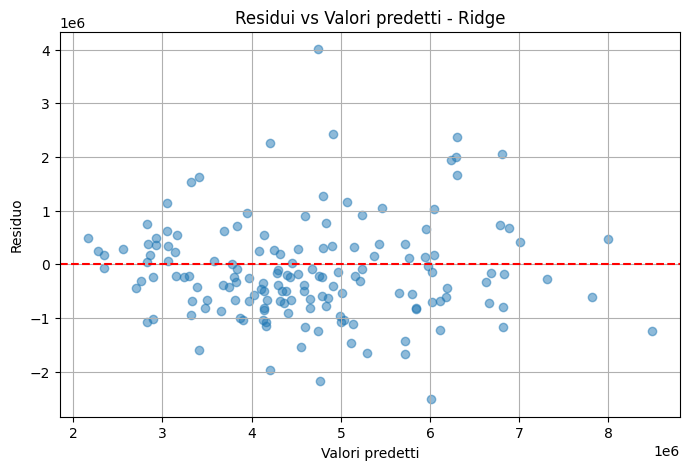

In [698]:
y_pred = modelR.predict(X_test)
residui = y_test - y_pred

plt.figure(figsize=(8,5))
sns.histplot(residui, kde=True, bins=30, color='skyblue')
plt.xlabel('Residuo')
plt.ylabel('Frequenza')
plt.title('Distribuzione dei residui - Ridge')
plt.grid()
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residui, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valori predetti')
plt.ylabel('Residuo')
plt.title('Residui vs Valori predetti - Ridge')
plt.grid()
plt.show()